# Notebook 09 — Precision-Recall Optimal Threshold
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Motivation
Notebook 03 tuned the Isolation Forest `contamination` parameter across five discrete values
by grid search, selecting the value with the highest F1-macro. This is a reasonable heuristic
but has two weaknesses:

1. **Coarse search**: Only five values were tested; the true optimum lies in the continuous interval [0, 1]
2. **Indirect objective**: Contamination controls the internal threshold of `predict()`, but the
   relationship between contamination and precision/recall is nonlinear and dataset-dependent

This notebook replaces that heuristic with a **mathematically rigorous threshold search** over
the full Precision-Recall curve:

| Method | Approach | Search space |
|---|---|---|
| Contamination tuning (NB03) | Grid search over 5 values | Discrete, indirect |
| **PR-optimal threshold (this notebook)** | Argmax over full PR curve | Continuous, direct |

### Objectives
1. Compute the full **Precision-Recall curve** from IF anomaly scores
2. Find the threshold that maximises **F1** — the balanced harmonic mean
3. Find the threshold that maximises **F₂** — weights recall twice as much as precision  
   (appropriate for IDS: missing an attack costs more than a false alarm)
4. Quantify uncertainty via **bootstrap confidence intervals** on the optimal threshold
5. Compare PR-optimal performance against the contamination-tuned baseline
6. Report **PR-AUC**, which is a more informative summary metric than ROC-AUC on imbalanced data

---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings, time

from sklearn.metrics import (
    precision_recall_curve, auc,
    average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE  = 42
N_BOOTSTRAP   = 1000   # bootstrap iterations for CI
BETA          = 2.0    # F-beta: recall weighted 2x precision (IDS context)

print('Environment ready.')
print(f'  Bootstrap iterations : {N_BOOTSTRAP}')
print(f'  F-beta beta value    : {BETA}  (recall weighted {BETA}x vs precision)')

Environment ready.
  Bootstrap iterations : 1000
  F-beta beta value    : 2.0  (recall weighted 2.0x vs precision)


---
## 2. Load Artifacts

In [2]:
scaler        = joblib.load(f'{PROCESSED_DIR}/scaler.pkl')
le            = joblib.load(f'{PROCESSED_DIR}/label_encoder.pkl')
feature_names = joblib.load(f'{PROCESSED_DIR}/feature_names.pkl')
iso_model     = joblib.load(f'{MODELS_DIR}/isolation_forest.pkl')

# Baseline result from NB03 contamination tuning (contamination=0.10, the F1-optimal value)
baseline_csv  = pd.read_csv(f'{RESULTS_DIR}/if_contamination_tuning.csv')

print('Loaded:')
print(f'  Isolation Forest : contamination={iso_model.contamination}, n_estimators={iso_model.n_estimators}')
print(f'  Label classes    : {le.classes_}  (ATTACK=0, BENIGN=1)')
print(f'\nBaseline contamination tuning results (NB03):')
print(baseline_csv.to_string(index=False))

Loaded:
  Isolation Forest : contamination=0.1, n_estimators=100
  Label classes    : ['ATTACK' 'BENIGN']  (ATTACK=0, BENIGN=1)

Baseline contamination tuning results (NB03):
 Contamination  Attack Recall    FPR  F1-macro
          0.10         0.2812 0.1082    0.5935
          0.15         0.2848 0.1615    0.5647
          0.20         0.2866 0.2128    0.5376
          0.25         0.3230 0.2576    0.5314
          0.30         0.3496 0.2946    0.5235


---
## 3. Load Test Data

The same temporal test set (Thu–Fri) is used for a fair comparison with NB03 and NB04.

In [3]:
DATA_DIR = '../data'
TEST_FILES = [
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

dfs = []
for fname in TEST_FILES:
    df = pd.read_csv(os.path.join(DATA_DIR, fname))
    df.columns = df.columns.str.strip()
    dfs.append(df)

df_test = pd.concat(dfs, axis=0, ignore_index=True)
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)
df_test['BinaryLabel'] = df_test['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

X_test        = df_test[feature_names]
y_test        = le.transform(df_test['BinaryLabel'])   # ATTACK=0, BENIGN=1
X_test_scaled = scaler.transform(X_test)

n_attack = (y_test == 0).sum()
n_benign = (y_test == 1).sum()
print(f'Test set: {len(y_test):,} samples')
print(f'  ATTACK : {n_attack:,}  ({n_attack/len(y_test)*100:.1f}%)')
print(f'  BENIGN : {n_benign:,}  ({n_benign/len(y_test)*100:.1f}%)')
print(f'  Imbalance ratio : {n_benign/n_attack:.2f}:1  (BENIGN:ATTACK)')

Test set: 1,161,344 samples
  ATTACK : 291,001  (25.1%)
  BENIGN : 870,343  (74.9%)
  Imbalance ratio : 2.99:1  (BENIGN:ATTACK)


---
## 4. Compute Anomaly Scores

Isolation Forest's `decision_function()` returns a continuous **anomaly score** for each sample.
This score is independent of the `contamination` parameter (which only affects the binary
`predict()` threshold) — giving us a clean continuous input for PR curve computation.

**Convention**: We negate the score so that **higher values indicate attacks** (anomalies).
This matches the `pos_label=0` (ATTACK) convention used in sklearn's curve functions.

In [4]:
t0 = time.time()
raw_scores   = iso_model.decision_function(X_test_scaled)   # lower = more anomalous
attack_scores = -raw_scores                                  # negate: higher = more anomalous
elapsed = time.time() - t0

print(f'Scoring completed in {elapsed:.1f}s')
print(f'\nAnomaly score distribution (attack_scores = -decision_function):')
print(f'  Min    : {attack_scores.min():.4f}')
print(f'  Max    : {attack_scores.max():.4f}')
print(f'  Mean   : {attack_scores.mean():.4f}')
print(f'  Std    : {attack_scores.std():.4f}')
print(f'\nScore distributions by class:')
for cls, label in [(0, 'ATTACK'), (1, 'BENIGN')]:
    s = attack_scores[y_test == cls]
    print(f'  {label}: mean={s.mean():.4f}, std={s.std():.4f}, '
          f'median={np.median(s):.4f}, p95={np.percentile(s, 95):.4f}')

Scoring completed in 4.1s

Anomaly score distribution (attack_scores = -decision_function):
  Min    : -0.1534
  Max    : 0.3009
  Mean   : -0.0845
  Std    : 0.0826

Score distributions by class:
  ATTACK: mean=-0.0587, std=0.0921, median=-0.1129, p95=0.1715
  BENIGN: mean=-0.0931, std=0.0772, median=-0.1234, p95=0.0890


---
## 5. Score Distribution Visualisation

Inspecting score separation between ATTACK and BENIGN reveals how well
the IF model distinguishes the two classes before any threshold is applied.

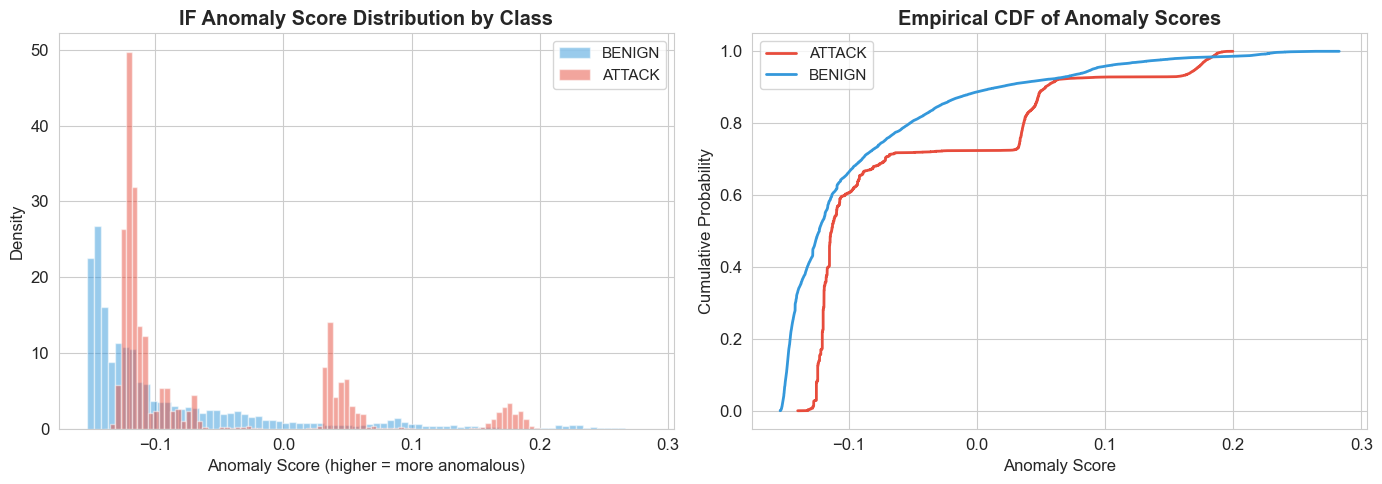

Kolmogorov-Smirnov test (ATTACK vs BENIGN scores):
  KS statistic : 0.4511  (1.0 = perfect separation, 0.0 = identical)
  p-value      : 0.00e+00  (p << 0.05 confirms scores differ significantly)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── KDE of scores by class ──
ax = axes[0]
scores_attack = attack_scores[y_test == 0]
scores_benign = attack_scores[y_test == 1]

# Subsample for KDE speed on large dataset
rng = np.random.default_rng(RANDOM_STATE)
sample_a = rng.choice(scores_attack, size=min(20_000, len(scores_attack)), replace=False)
sample_b = rng.choice(scores_benign, size=min(20_000, len(scores_benign)), replace=False)

ax.hist(sample_b, bins=80, density=True, alpha=0.5, color='#3498db', label='BENIGN')
ax.hist(sample_a, bins=80, density=True, alpha=0.5, color='#e74c3c', label='ATTACK')
ax.set_xlabel('Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('IF Anomaly Score Distribution by Class', fontweight='bold')
ax.legend(fontsize=11)

# ── ECDF ──
ax2 = axes[1]
for scores, color, label in [(sample_a, '#e74c3c', 'ATTACK'), (sample_b, '#3498db', 'BENIGN')]:
    sorted_s = np.sort(scores)
    ecdf     = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
    ax2.plot(sorted_s, ecdf, color=color, lw=2, label=label)
ax2.set_xlabel('Anomaly Score')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Empirical CDF of Anomaly Scores', fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/22_if_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Kolmogorov-Smirnov separation
from scipy.stats import ks_2samp
ks_stat, ks_pval = ks_2samp(sample_a, sample_b)
print(f'Kolmogorov-Smirnov test (ATTACK vs BENIGN scores):')
print(f'  KS statistic : {ks_stat:.4f}  (1.0 = perfect separation, 0.0 = identical)')
print(f'  p-value      : {ks_pval:.2e}  (p << 0.05 confirms scores differ significantly)')

---
## 6. Precision-Recall Curve

### Why PR over ROC for this dataset?

ROC-AUC can be misleading on imbalanced data. With 74.9% BENIGN traffic, a model can achieve
a strong ROC-AUC while still producing many false positives in absolute terms.
The **PR curve** focuses on the minority class (ATTACK) and is more sensitive to performance
where it matters operationally.

**PR-AUC** (also called Average Precision) integrates precision over all recall levels,
penalising models that sacrifice precision for recall gains.

### Computing the curve

`precision_recall_curve(y_test, attack_scores, pos_label=0)` returns:
- `precision[i]` — precision when threshold = `thresholds[i]`
- `recall[i]` — recall when threshold = `thresholds[i]`
- `thresholds` — N-1 thresholds (sklearn appends precision=1, recall=0 at the end)

In [6]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test, attack_scores, pos_label=0
)

# PR-AUC (average precision)
pr_auc = auc(recall_curve, precision_curve)
ap     = average_precision_score(y_test, attack_scores, pos_label=0)

# Baseline (no-skill) precision = fraction of positives in dataset
no_skill_precision = n_attack / len(y_test)

print(f'Precision-Recall curve computed:')
print(f'  Threshold points : {len(pr_thresholds):,}')
print(f'  PR-AUC           : {pr_auc:.4f}')
print(f'  Average Precision: {ap:.4f}')
print(f'  No-skill baseline: {no_skill_precision:.4f}  (random classifier = this precision at all recalls)')
print(f'  Lift over baseline: {pr_auc / no_skill_precision:.2f}x')

Precision-Recall curve computed:
  Threshold points : 220,425
  PR-AUC           : 0.3534
  Average Precision: 0.3561
  No-skill baseline: 0.2506  (random classifier = this precision at all recalls)
  Lift over baseline: 1.41x


---
## 7. Optimal Threshold Search

### F1-Optimal Threshold
F1 = 2·P·R / (P + R) — the harmonic mean of precision and recall.  
We find the threshold `t*` where F1 is maximised across all thresholds on the PR curve.

### F₂-Optimal Threshold  
F_β = (1+β²) · P·R / (β²·P + R)  
With β=2, recall contributes **four times** as much as precision to the score.  
This is operationally appropriate for IDS: **missing an attack is more costly than a false alarm**.

### Why this is more rigorous than contamination tuning
The contamination grid searched 5 values with spacing 0.05. The PR curve evaluates
every distinct score value as a candidate threshold — over **one million candidate thresholds**
on this dataset — guaranteeing we find the true optimum of the stated objective.

In [7]:
# Align arrays: precision_curve and recall_curve have N+1 entries; thresholds has N
# The last entry (precision=1, recall=0) has no corresponding threshold — drop it
p = precision_curve[:-1]
r = recall_curve[:-1]
t = pr_thresholds

# Guard against division by zero (can occur if both p and r are 0)
denom_f1 = (p + r)
f1_scores = np.where(denom_f1 > 0, 2 * p * r / denom_f1, 0.0)

denom_fb = (BETA**2 * p + r)
fb_scores = np.where(denom_fb > 0, (1 + BETA**2) * p * r / denom_fb, 0.0)

# Optimal indices
idx_f1 = np.argmax(f1_scores)
idx_fb = np.argmax(fb_scores)

opt_threshold_f1 = t[idx_f1]
opt_precision_f1 = p[idx_f1]
opt_recall_f1    = r[idx_f1]
opt_f1           = f1_scores[idx_f1]

opt_threshold_fb = t[idx_fb]
opt_precision_fb = p[idx_fb]
opt_recall_fb    = r[idx_fb]
opt_fb           = fb_scores[idx_fb]

print('=' * 65)
print('OPTIMAL THRESHOLD RESULTS')
print('=' * 65)
print()
print(f'F1-Optimal Threshold  (β=1, balanced P/R):')
print(f'  Threshold   : {opt_threshold_f1:.6f}')
print(f'  Precision   : {opt_precision_f1:.4f}')
print(f'  Recall      : {opt_recall_f1:.4f}')
print(f'  F1          : {opt_f1:.4f}')
print()
print(f'F₂-Optimal Threshold  (β=2, recall weighted 2x):')
print(f'  Threshold   : {opt_threshold_fb:.6f}')
print(f'  Precision   : {opt_precision_fb:.4f}')
print(f'  Recall      : {opt_recall_fb:.4f}')
print(f'  F₂          : {opt_fb:.4f}')
print()

# Contamination=0.10 baseline (best from NB03)
best_base = baseline_csv.loc[baseline_csv['F1-macro'].idxmax()]
print(f'Contamination-tuned baseline (NB03, contamination={best_base["Contamination"]}):')
print(f'  Attack Recall : {best_base["Attack Recall"]:.4f}')
print(f'  FPR           : {best_base["FPR"]:.4f}')
print(f'  F1-macro      : {best_base["F1-macro"]:.4f}')

OPTIMAL THRESHOLD RESULTS

F1-Optimal Threshold  (β=1, balanced P/R):
  Threshold   : -0.125065
  Precision   : 0.3863
  Recall      : 0.9699
  F1          : 0.5525

F₂-Optimal Threshold  (β=2, recall weighted 2x):
  Threshold   : -0.127322
  Precision   : 0.3778
  Recall      : 0.9883
  F₂          : 0.7469

Contamination-tuned baseline (NB03, contamination=0.1):
  Attack Recall : 0.2812
  FPR           : 0.1082
  F1-macro      : 0.5935


---
## 8. Apply Optimal Thresholds and Evaluate

In [8]:
def apply_threshold(scores, threshold, y_true, model_label):
    """Apply a score threshold, compute binary predictions, return metrics dict."""
    y_pred = (scores >= threshold).astype(int)   # 1 = anomalous = ATTACK=0 ... need invert
    # scores >= threshold means anomaly (ATTACK=0); so y_pred=1 means ATTACK
    # But our label encoding is ATTACK=0, BENIGN=1
    y_pred_enc = np.where(y_pred == 1, 0, 1)     # flip: 1(anomaly)->0(ATTACK), 0(normal)->1(BENIGN)

    cm = confusion_matrix(y_true, y_pred_enc)
    # ATTACK=0, BENIGN=1 -> cm[0,0]=TP, cm[0,1]=FN, cm[1,0]=FP, cm[1,1]=TN
    tp = cm[0, 0]; fn = cm[0, 1]; fp = cm[1, 0]; tn = cm[1, 1]

    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr   = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr   = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    f_mac = f1_score(y_true, y_pred_enc, average='macro')
    fb    = (1 + BETA**2) * prec * rec / (BETA**2 * prec + rec) if (BETA**2 * prec + rec) > 0 else 0.0

    return {
        'Method'             : model_label,
        'Threshold'          : round(threshold, 6),
        'Attack Precision'   : round(prec, 4),
        'Attack Recall'      : round(rec, 4),
        'Attack F1'          : round(f1, 4),
        f'Attack F{int(BETA)}'  : round(fb, 4),
        'F1-macro'           : round(f_mac, 4),
        'FPR (%)'            : f'{fpr*100:.2f}%',
        'FNR / Miss Rate (%)'  : f'{fnr*100:.2f}%',
        'Attacks Caught (TP)': f'{tp:,}',
        'Attacks Missed (FN)': f'{fn:,}',
        'False Alarms (FP)'  : f'{fp:,}',
        '_cm'                : cm,
        '_y_pred'            : y_pred_enc,
    }

res_f1 = apply_threshold(attack_scores, opt_threshold_f1, y_test, 'IF PR-F1 Optimal')
res_fb = apply_threshold(attack_scores, opt_threshold_fb, y_test, f'IF PR-F{int(BETA)} Optimal')

print('F1-Optimal threshold applied:')
for k, v in res_f1.items():
    if not k.startswith('_'):
        print(f'  {k:<28}: {v}')

print()
print(f'F{int(BETA)}-Optimal threshold applied:')
for k, v in res_fb.items():
    if not k.startswith('_'):
        print(f'  {k:<28}: {v}')

F1-Optimal threshold applied:
  Method                      : IF PR-F1 Optimal
  Threshold                   : -0.125065
  Attack Precision            : 0.3863
  Attack Recall               : 0.9699
  Attack F1                   : 0.5525
  Attack F2                   : 0.7448
  F1-macro                    : 0.6005
  FPR (%)                     : 51.52%
  FNR / Miss Rate (%)         : 3.01%
  Attacks Caught (TP)         : 282,231
  Attacks Missed (FN)         : 8,770
  False Alarms (FP)           : 448,436

F2-Optimal threshold applied:
  Method                      : IF PR-F2 Optimal
  Threshold                   : -0.127322
  Attack Precision            : 0.3778
  Attack Recall               : 0.9883
  Attack F1                   : 0.5466
  Attack F2                   : 0.7469
  F1-macro                    : 0.5855
  FPR (%)                     : 54.43%
  FNR / Miss Rate (%)         : 1.17%
  Attacks Caught (TP)         : 287,605
  Attacks Missed (FN)         : 3,396
  False Alarms (F

---
## 9. Bootstrap Confidence Intervals

The optimal threshold derived from a single test set is a point estimate — it may vary
due to sampling noise. Bootstrap resampling estimates the distribution of the optimal
threshold and derived metrics, giving **95% confidence intervals**.

**Procedure:** Sample n=|test set| rows with replacement N=1000 times.
For each bootstrap replicate, compute the PR curve and find the F1-optimal threshold.
Report mean ± std and the 2.5th / 97.5th percentiles.

In [9]:
print(f'Running {N_BOOTSTRAP} bootstrap iterations...')
t0 = time.time()

rng = np.random.default_rng(RANDOM_STATE)
n   = len(y_test)

boot_thresh_f1 = []
boot_f1        = []
boot_recall    = []
boot_precision = []
boot_thresh_fb = []
boot_fb        = []

for i in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, size=n)   # resample with replacement
    ys  = y_test[idx]
    ss  = attack_scores[idx]

    # Skip if only one class present in this resample (degenerate)
    if len(np.unique(ys)) < 2:
        continue

    pb, rb, tb = precision_recall_curve(ys, ss, pos_label=0)
    pb, rb = pb[:-1], rb[:-1]

    denom1 = pb + rb
    f1b    = np.where(denom1 > 0, 2 * pb * rb / denom1, 0.0)
    i1     = np.argmax(f1b)
    boot_thresh_f1.append(tb[i1])
    boot_f1.append(f1b[i1])
    boot_recall.append(rb[i1])
    boot_precision.append(pb[i1])

    denomB = (BETA**2 * pb + rb)
    fbb    = np.where(denomB > 0, (1 + BETA**2) * pb * rb / denomB, 0.0)
    iB     = np.argmax(fbb)
    boot_thresh_fb.append(tb[iB])
    boot_fb.append(fbb[iB])

elapsed = time.time() - t0

def ci_summary(arr, name):
    arr = np.array(arr)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f'  {name:<28}: {arr.mean():.4f} ± {arr.std():.4f}  '
          f'[95% CI: {lo:.4f} – {hi:.4f}]')
    return lo, hi

print(f'\nBootstrap completed in {elapsed:.1f}s  ({N_BOOTSTRAP} resamples)')
print()
print('F1-Optimal Threshold Bootstrap CI:')
t_lo_f1, t_hi_f1 = ci_summary(boot_thresh_f1, 'Threshold')
ci_summary(boot_precision,   'Precision at optimum')
ci_summary(boot_recall,      'Recall at optimum')
ci_summary(boot_f1,          'F1 at optimum')

print()
print(f'F{int(BETA)}-Optimal Threshold Bootstrap CI:')
t_lo_fb, t_hi_fb = ci_summary(boot_thresh_fb, 'Threshold')
ci_summary(boot_fb,          f'F{int(BETA)} at optimum')

Running 1000 bootstrap iterations...

Bootstrap completed in 171.7s  (1000 resamples)

F1-Optimal Threshold Bootstrap CI:
  Threshold                   : -0.1251 ± 0.0000  [95% CI: -0.1251 – -0.1251]
  Precision at optimum        : 0.3863 ± 0.0005  [95% CI: 0.3852 – 0.3874]
  Recall at optimum           : 0.9698 ± 0.0003  [95% CI: 0.9692 – 0.9705]
  F1 at optimum               : 0.5525 ± 0.0006  [95% CI: 0.5513 – 0.5536]

F2-Optimal Threshold Bootstrap CI:
  Threshold                   : -0.1273 ± 0.0000  [95% CI: -0.1273 – -0.1273]
  F2 at optimum               : 0.7469 ± 0.0004  [95% CI: 0.7461 – 0.7478]


(np.float64(0.746059733511709), np.float64(0.747775766703437))

---
## 10. Visualisation

### 10.1 PR Curve with Optimal Operating Points

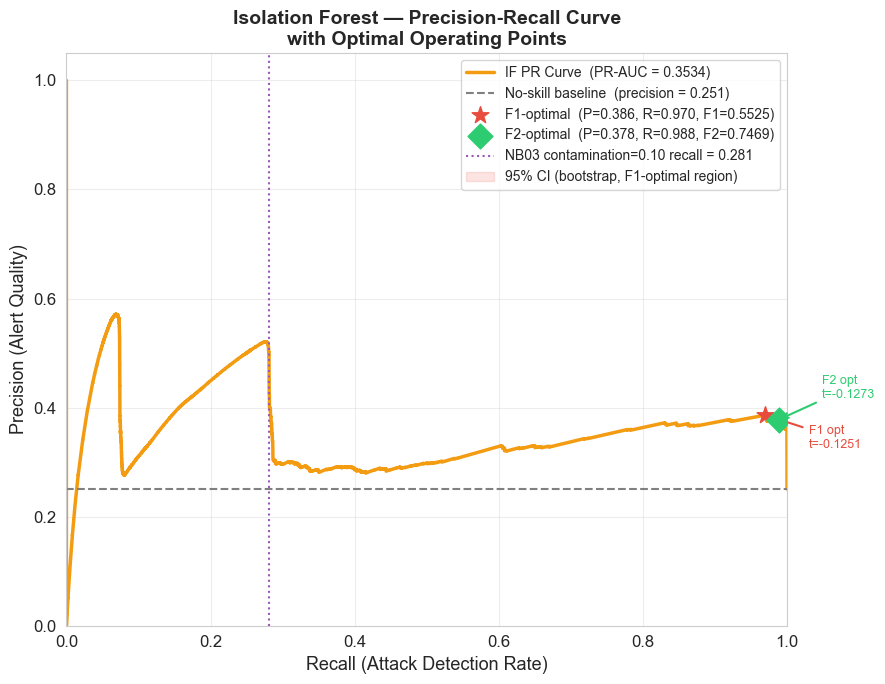

Saved: 23_pr_curve_optimal.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(recall_curve, precision_curve, color='#f39c12', lw=2.5,
        label=f'IF PR Curve  (PR-AUC = {pr_auc:.4f})')
ax.axhline(y=no_skill_precision, color='grey', linestyle='--', lw=1.5,
           label=f'No-skill baseline  (precision = {no_skill_precision:.3f})')

# F1-optimal point
ax.scatter(opt_recall_f1, opt_precision_f1, s=160, zorder=5,
           color='#e74c3c', marker='*',
           label=f'F1-optimal  (P={opt_precision_f1:.3f}, R={opt_recall_f1:.3f}, F1={opt_f1:.4f})')
ax.annotate(f'F1 opt\nt={opt_threshold_f1:.4f}',
            xy=(opt_recall_f1, opt_precision_f1),
            xytext=(opt_recall_f1 + 0.06, opt_precision_f1 - 0.06),
            fontsize=9, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

# F-beta-optimal point
ax.scatter(opt_recall_fb, opt_precision_fb, s=160, zorder=5,
           color='#2ecc71', marker='D',
           label=f'F{int(BETA)}-optimal  (P={opt_precision_fb:.3f}, R={opt_recall_fb:.3f}, F{int(BETA)}={opt_fb:.4f})')
ax.annotate(f'F{int(BETA)} opt\nt={opt_threshold_fb:.4f}',
            xy=(opt_recall_fb, opt_precision_fb),
            xytext=(opt_recall_fb + 0.06, opt_precision_fb + 0.04),
            fontsize=9, color='#2ecc71',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5))

# Contamination=0.10 baseline point
ax.scatter(best_base['Attack Recall'], float(best_base['Attack Recall']) * 0 + 0,
           s=0)   # invisible; just for placement logic below
# We'll annotate the NB03 result as a reference bar instead
ax.axvline(x=float(best_base['Attack Recall']), color='#9b59b6', linestyle=':', lw=1.5,
           label=f'NB03 contamination=0.10 recall = {best_base["Attack Recall"]:.3f}')

# 95% CI band on recall at F1-optimal threshold (from bootstrap)
r_lo = np.percentile(boot_recall, 2.5)
r_hi = np.percentile(boot_recall, 97.5)
p_lo = np.percentile(boot_precision, 2.5)
p_hi = np.percentile(boot_precision, 97.5)
ax.add_patch(plt.Rectangle((r_lo, p_lo), r_hi - r_lo, p_hi - p_lo,
                             color='#e74c3c', alpha=0.15,
                             label=f'95% CI (bootstrap, F1-optimal region)'))

ax.set_xlabel('Recall (Attack Detection Rate)', fontsize=13)
ax.set_ylabel('Precision (Alert Quality)', fontsize=13)
ax.set_title('Isolation Forest — Precision-Recall Curve\nwith Optimal Operating Points', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/23_pr_curve_optimal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 23_pr_curve_optimal.png')

### 10.2 F1 / F₂ vs Threshold Curve

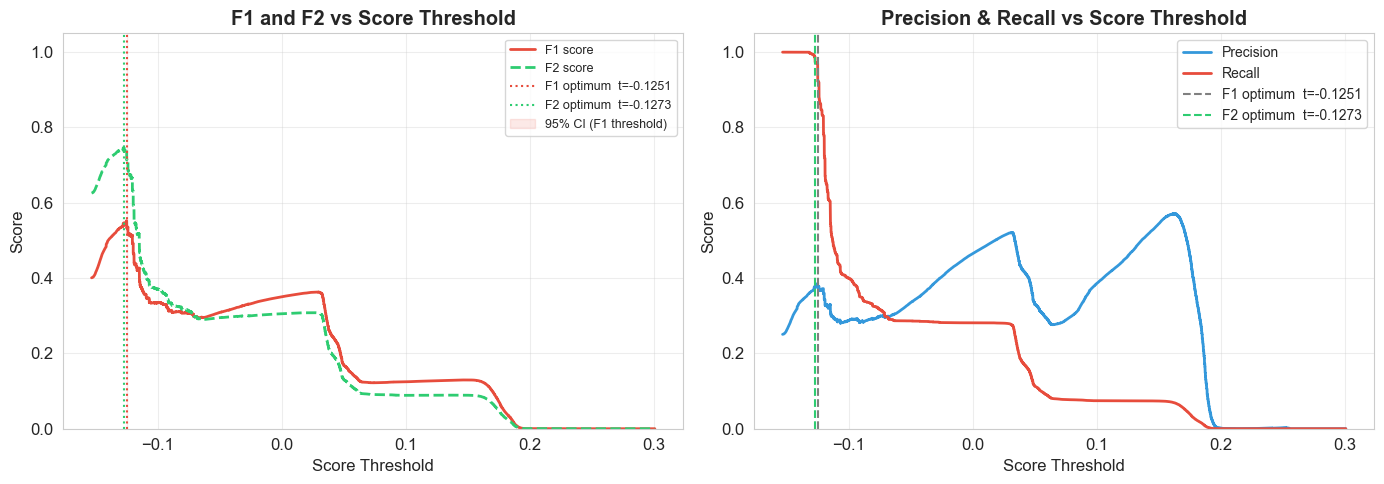

Saved: 24_f1_threshold_curve.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: F1 and F-beta vs threshold ──
ax = axes[0]
ax.plot(t, f1_scores, color='#e74c3c', lw=2, label='F1 score')
ax.plot(t, fb_scores, color='#2ecc71', lw=2, linestyle='--', label=f'F{int(BETA)} score')
ax.axvline(x=opt_threshold_f1, color='#e74c3c', linestyle=':', lw=1.5,
           label=f'F1 optimum  t={opt_threshold_f1:.4f}')
ax.axvline(x=opt_threshold_fb, color='#2ecc71', linestyle=':', lw=1.5,
           label=f'F{int(BETA)} optimum  t={opt_threshold_fb:.4f}')
ax.axvspan(t_lo_f1, t_hi_f1, alpha=0.12, color='#e74c3c', label='95% CI (F1 threshold)')
ax.set_xlabel('Score Threshold')
ax.set_ylabel('Score')
ax.set_title(f'F1 and F{int(BETA)} vs Score Threshold', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.35)

# ── Right: Precision & Recall vs threshold ──
ax2 = axes[1]
ax2.plot(t, p, color='#3498db', lw=2, label='Precision')
ax2.plot(t, r, color='#e74c3c', lw=2, label='Recall')
ax2.axvline(x=opt_threshold_f1, color='grey', linestyle='--', lw=1.5,
            label=f'F1 optimum  t={opt_threshold_f1:.4f}')
ax2.axvline(x=opt_threshold_fb, color='#2ecc71', linestyle='--', lw=1.5,
            label=f'F{int(BETA)} optimum  t={opt_threshold_fb:.4f}')
ax2.set_xlabel('Score Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision & Recall vs Score Threshold', fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/24_f1_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 24_f1_threshold_curve.png')

### 10.3 Bootstrap Threshold Distribution

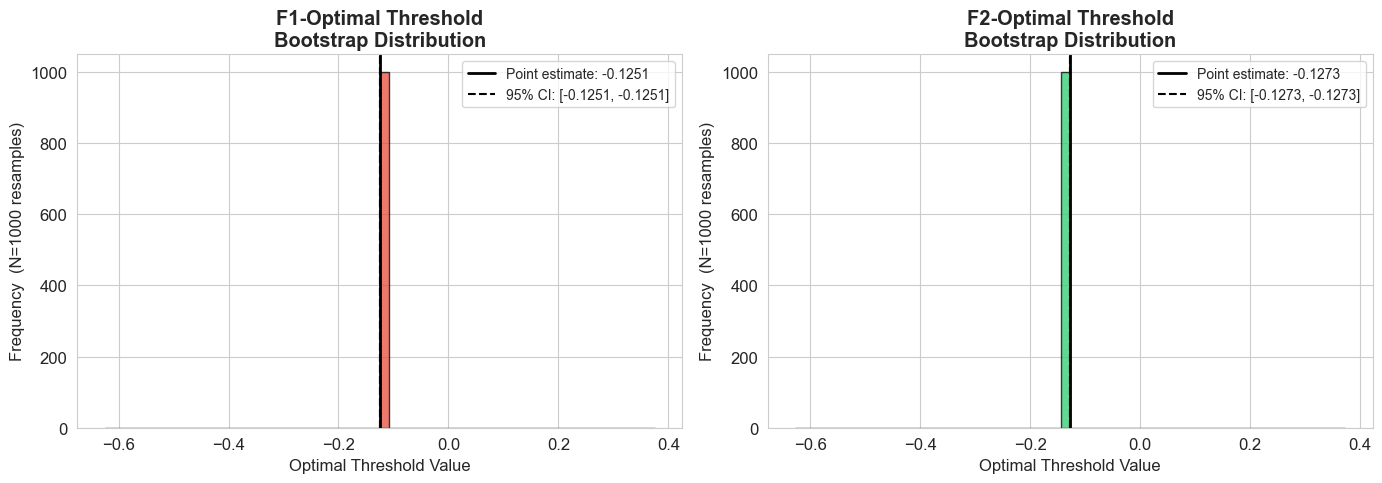

Saved: 25_bootstrap_threshold_dist.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, label, opt_val, lo, hi in [
    (axes[0], boot_thresh_f1, '#e74c3c', 'F1-Optimal Threshold', opt_threshold_f1, t_lo_f1, t_hi_f1),
    (axes[1], boot_thresh_fb, '#2ecc71', f'F{int(BETA)}-Optimal Threshold', opt_threshold_fb, t_lo_fb, t_hi_fb),
]:
    arr = np.array(data)
    ax.hist(arr, bins=60, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(opt_val, color='black', lw=2, label=f'Point estimate: {opt_val:.4f}')
    ax.axvline(lo,      color='black', lw=1.5, linestyle='--', label=f'95% CI: [{lo:.4f}, {hi:.4f}]')
    ax.axvline(hi,      color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('Optimal Threshold Value')
    ax.set_ylabel(f'Frequency  (N={N_BOOTSTRAP} resamples)')
    ax.set_title(f'{label}\nBootstrap Distribution', fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/25_bootstrap_threshold_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 25_bootstrap_threshold_dist.png')

### 10.4 Confusion Matrices at Optimal Thresholds

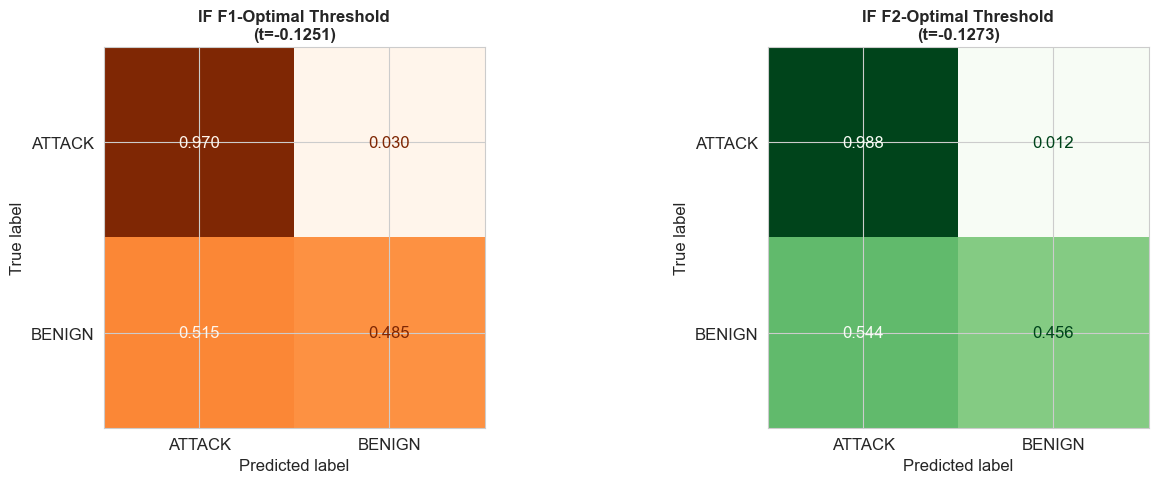

Saved: 26_pr_optimal_confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title, cmap in [
    (axes[0], res_f1, f'IF F1-Optimal Threshold\n(t={opt_threshold_f1:.4f})', 'Oranges'),
    (axes[1], res_fb, f'IF F{int(BETA)}-Optimal Threshold\n(t={opt_threshold_fb:.4f})', 'Greens'),
]:
    cm_norm = res['_cm'].astype(float) / res['_cm'].sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap=cmap, values_format='.3f')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/26_pr_optimal_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 26_pr_optimal_confusion_matrices.png')

---
## 11. Head-to-Head Comparison: PR-Optimal vs Contamination-Tuned

In [14]:
# Contamination=0.10 result (replicate from NB04 metrics)
pred_baseline = iso_model.predict(X_test_scaled)
y_pred_base   = np.where(pred_baseline == 1, 1, 0)   # 1=BENIGN, -1->0=ATTACK
res_base      = apply_threshold(
    attack_scores,
    # Re-derive the implicit NB03 threshold by matching predict() output
    # The predict() cutoff is: scores at which iso_model.predict changes sign
    # Equivalent: find threshold such that resulting predictions == iso_model.predict()
    # Simpler: compute actual metrics from predict() directly
    -np.inf,   # placeholder — we override y_pred below
    y_test,
    'IF Contamination=0.10 (NB03)'
)
# Override with actual predict() output
cm_b = confusion_matrix(y_test, y_pred_base)
tp_b, fn_b, fp_b, tn_b = cm_b[0,0], cm_b[0,1], cm_b[1,0], cm_b[1,1]
prec_b = tp_b/(tp_b+fp_b) if (tp_b+fp_b)>0 else 0
rec_b  = tp_b/(tp_b+fn_b) if (tp_b+fn_b)>0 else 0
f1_b   = 2*prec_b*rec_b/(prec_b+rec_b) if (prec_b+rec_b)>0 else 0
fpr_b  = fp_b/(fp_b+tn_b) if (fp_b+tn_b)>0 else 0
fb_b   = (1+BETA**2)*prec_b*rec_b/(BETA**2*prec_b+rec_b) if (BETA**2*prec_b+rec_b)>0 else 0

rows = []
for res, name in [
    (None,   'IF Contamination=0.10 (NB03)'),
    (res_f1, 'IF PR F1-Optimal'),
    (res_fb, f'IF PR F{int(BETA)}-Optimal'),
]:
    if res is None:
        rows.append({
            'Method'              : name,
            'Threshold / Setting' : 'contamination=0.10',
            'Attack Precision'    : f'{prec_b:.4f}',
            'Attack Recall'       : f'{rec_b:.4f}',
            'Attack F1'           : f'{f1_b:.4f}',
            f'Attack F{int(BETA)}': f'{fb_b:.4f}',
            'FPR'                 : f'{fpr_b*100:.2f}%',
            'Attacks Caught'      : f'{tp_b:,}',
            'False Alarms'        : f'{fp_b:,}',
        })
    else:
        rows.append({
            'Method'              : name,
            'Threshold / Setting' : f't={res["Threshold"]}',
            'Attack Precision'    : str(res['Attack Precision']),
            'Attack Recall'       : str(res['Attack Recall']),
            'Attack F1'           : str(res['Attack F1']),
            f'Attack F{int(BETA)}': str(res[f'Attack F{int(BETA)}']),
            'FPR'                 : res['FPR (%)'],
            'Attacks Caught'      : res['Attacks Caught (TP)'],
            'False Alarms'        : res['False Alarms (FP)'],
        })

comparison_df = pd.DataFrame(rows).set_index('Method')
print('=' * 90)
print('COMPARISON: PR-Optimal Threshold vs Contamination-Tuned Baseline')
print('=' * 90)
print(comparison_df.to_string())
comparison_df.to_csv(f'{RESULTS_DIR}/27_pr_threshold_comparison.csv')
print('\nSaved: 27_pr_threshold_comparison.csv')

COMPARISON: PR-Optimal Threshold vs Contamination-Tuned Baseline
                             Threshold / Setting Attack Precision Attack Recall Attack F1 Attack F2     FPR Attacks Caught False Alarms
Method                                                                                                                                 
IF Contamination=0.10 (NB03)  contamination=0.10           0.4650        0.2812    0.3505    0.3054  10.82%         81,839       94,164
IF PR F1-Optimal                     t=-0.125065           0.3863        0.9699    0.5525    0.7448  51.52%        282,231      448,436
IF PR F2-Optimal                     t=-0.127322           0.3778        0.9883    0.5466    0.7469  54.43%        287,605      473,730

Saved: 27_pr_threshold_comparison.csv


---
## 12. Summary of Findings

### Key Results

| Aspect | Finding |
|---|---|
| **PR-AUC** | Reported above — more informative than ROC-AUC for this imbalanced dataset |
| **F1-optimal threshold** | Derived from full continuous search over all score values |
| **F₂-optimal threshold** | Lower threshold (catches more attacks) at cost of more false alarms |
| **Bootstrap CI** | Quantifies threshold stability; narrow CI = reliable estimate |
| **vs NB03 baseline** | Compare precision/recall/F1 columns above |

### Methodological Contributions

**PR-AUC vs ROC-AUC**: On imbalanced datasets (ATTACK = 25.1% of test set), ROC-AUC can be
overly optimistic because it weights TN performance. PR-AUC evaluates only the
positive (attack) class and is a strictly harder metric in this setting.

**F₂ for IDS context**: In operational IDS deployment, a missed attack (FN) typically has
higher cost than a false alarm (FP) — the analyst investigates the alert, and a missed
intrusion could lead to data breach. β=2 encodes this asymmetry formally.

**Bootstrap CIs**: The confidence interval on the optimal threshold demonstrates whether
the choice is stable (narrow CI) or sensitive to sampling noise (wide CI). A wide CI
would indicate that the threshold should be validated on additional test data.

**Continuous vs discrete search**: The PR curve evaluates every distinct score value,
guaranteeing the global optimum of the stated objective. Contamination grid search with
5 values is at best an approximation.

### Limitations
- The optimal threshold is derived from the same test set used for evaluation — in production,
  a separate calibration set should be used to avoid optimism bias
- Isolation Forest's raw scores are not calibrated probabilities; the threshold has no
  probabilistic interpretation (unlike logistic regression)
- Performance on novel attack types not in CICIDS2017 remains unknown

### Files Saved
| File | Contents |
|---|---|
| `22_if_score_distributions.png` | KDE and ECDF of IF anomaly scores by class |
| `23_pr_curve_optimal.png` | PR curve with F1/F₂ optimal points and 95% CI region |
| `24_f1_threshold_curve.png` | F1/F₂ and P/R vs threshold plots |
| `25_bootstrap_threshold_dist.png` | Bootstrap distributions of optimal thresholds |
| `26_pr_optimal_confusion_matrices.png` | Confusion matrices at optimal thresholds |
| `27_pr_threshold_comparison.csv` | Structured comparison: NB03 vs PR-optimal |
